# Bottleneck & Latent Space Optimization Analysis

In this notebook, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

## Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm


# Runtime reload
import importlib
import models.autoencoder.selected_model
importlib.reload(models.autoencoder.selected_model)


from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.selected_model import (
    BaseEncoder,
    BaseDecoder,
    BottleneckEncoder,
    BottleneckBasisDecoder,
    BottleneckHybridDecoder,
    BottleneckDeconvDecoder,
    BottleneckAE,
    SpatialAE,
    BottleneckBasisDecoderFixed,
    BottleneckDeconvDecoderFixed,
    BottleneckHybridDecoderFixed
)
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_model(m, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(m.state_dict(), path)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Device: cuda


## Data setup

In [5]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/NotebookBottelneckBestModel-12-11"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [3]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=2
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [4]:
target_shape = (64, 128, 128)

def build_model(variant, latent_dim=128, bottleneck_shape=(1,1,1), basis_groups="partial"):
    if variant == "vanilla":
        model = SpatialAE(
            BaseEncoder(initial_filters=4),
            BaseDecoder(latent_dim=latent_dim),
        )
    elif variant == "basis":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckBasisDecoder(latent_dim=latent_dim, target_shape=target_shape, groups=basis_groups),
        )
    elif variant == "deconv":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        )
    elif variant == "hybrid":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckHybridDecoderFixed(latent_dim=latent_dim, target_shape=target_shape),
        )
    else:
        raise ValueError(f"Unknown variant {variant}")
    return model.to(device)

In [6]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

In [7]:
# Latent dimensions to test: 512, 256, 128, 64, 32
latent_dims = [512, 256, 128, 64, 32]
group_types = ["full", "partial", "none"]

settings = []
for latent_dim in latent_dims:
    for groups in group_types:
        settings.append(("basis", latent_dim, (1,1,1), groups))

# Also test deconv and hybrid for comparison
for latent_dim in latent_dims:
    settings.append(("deconv", latent_dim, (1,1,1), "full"))
    # settings.append(("hybrid", latent_dim, (1,1,1), "full"))

histories = {}
results_summary = []

# Set number of epochs
num_epochs = 30  # Reduced for faster iteration

In [8]:
settings

[('basis', 512, (1, 1, 1), 'full'),
 ('basis', 512, (1, 1, 1), 'partial'),
 ('basis', 512, (1, 1, 1), 'none'),
 ('basis', 256, (1, 1, 1), 'full'),
 ('basis', 256, (1, 1, 1), 'partial'),
 ('basis', 256, (1, 1, 1), 'none'),
 ('basis', 128, (1, 1, 1), 'full'),
 ('basis', 128, (1, 1, 1), 'partial'),
 ('basis', 128, (1, 1, 1), 'none'),
 ('basis', 64, (1, 1, 1), 'full'),
 ('basis', 64, (1, 1, 1), 'partial'),
 ('basis', 64, (1, 1, 1), 'none'),
 ('basis', 32, (1, 1, 1), 'full'),
 ('basis', 32, (1, 1, 1), 'partial'),
 ('basis', 32, (1, 1, 1), 'none'),
 ('deconv', 512, (1, 1, 1), 'full'),
 ('deconv', 256, (1, 1, 1), 'full'),
 ('deconv', 128, (1, 1, 1), 'full'),
 ('deconv', 64, (1, 1, 1), 'full'),
 ('deconv', 32, (1, 1, 1), 'full')]


[1/20] ================== Training basis_lat512_gfull ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 17.68M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gfull/basis_lat512_gfull_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gfull/basis_lat512_gfull_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:720: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv3d(
Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:39<13:21, 21.52it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gfull/basis_lat512_gfull_checkpoint.pth


...

Epoch 29/30 | Train: 0.006418 | Val: 0.006336 | LR: 0.00010000 | ETA: 0.59m

GPU Memory Usage:
Allocated: 202.39 MB
Cached: 280.00 MB
CPU Memory Usage: 1936.16 MB
DEBUG: EarlyStopping - Current val_loss: 0.006336, Best loss: 0.006307
Early stopping counter: 2/5
DEBUG: EarlyStopping - No improvement, counter increased to 2/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [17:36<00:00, 21.65it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [17:42<00:00, 16.79it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gfull/basis_lat512_gfull_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gfull/basis_lat512_gfull_metadata.json
Epoch 30/30 | Train: 0.006320 | Val: 0.006593 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 202.39 MB
Cached: 280.00 MB
CPU Memory Usage: 1939.91 MB
DEBUG: EarlyStopping - Current val_loss: 0.006593, Best loss: 0.006307
Early stopping counter: 3/5
DEBUG: EarlyStopping - No improvement, counter increased to 3/5
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gfull/basis_lat512_gfull_training_history.png


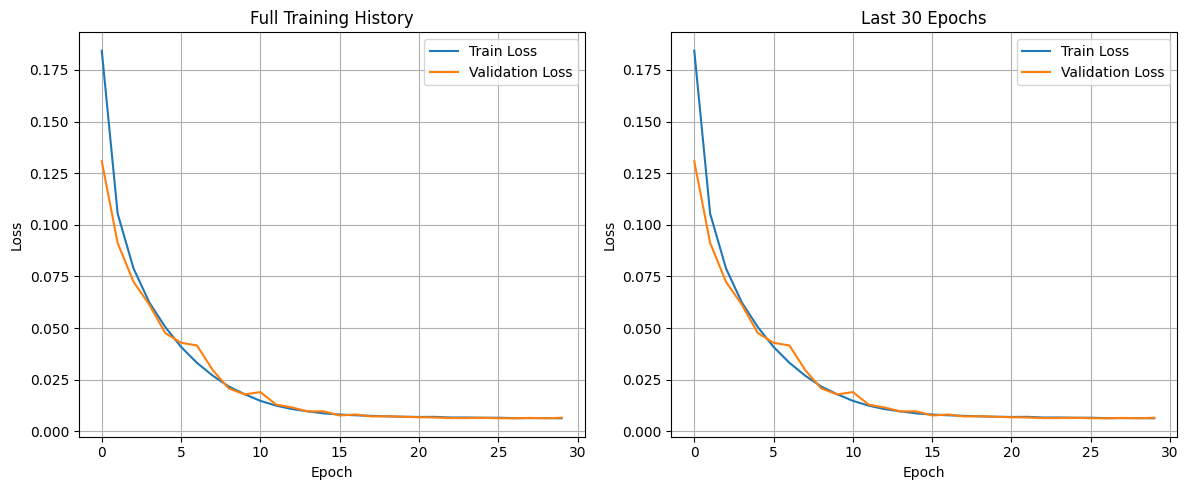

DEBUG: Plot saved and displayed successfully

Training completed in 17.72 minutes
Best validation loss: 0.006307
✓ Completed in 1064.1s | Final Val Loss: 0.006593

[2/20] ================== Training basis_lat512_gpartial ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 18.07M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:27<13:07, 21.90it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_checkpoint.pth


...

Epoch 24/30 | Train: 0.005603 | Val: 0.006074 | LR: 0.00010000 | ETA: 3.39m

GPU Memory Usage:
Allocated: 410.22 MB
Cached: 536.00 MB
CPU Memory Usage: 1971.93 MB
DEBUG: EarlyStopping - Current val_loss: 0.006074, Best loss: 0.005906
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 18.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Starting epoch 25/30


Progress [E25/30|Val]:  83%|█████████████████████████████████████████████         | 14875/17850 [14:00<02:12, 22.40it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 24
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_checkpoint.pth


Progress [E25/30|Val]:  83%|█████████████████████████████████████████████         | 14875/17850 [14:06<02:49, 17.58it/s]

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_metadata.json
Epoch 25/30 | Train: 0.005682 | Val: 0.005555 | LR: 0.00010000 | ETA: 2.82m

GPU Memory Usage:
Allocated: 410.22 MB
Cached: 536.00 MB
CPU Memory Usage: 1971.93 MB
DEBUG: EarlyStopping - Current val_loss: 0.005555, Best loss: 0.005906
Validation loss improved by 0.000351
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gpartial/basis_lat512_gpartial_training_history.png


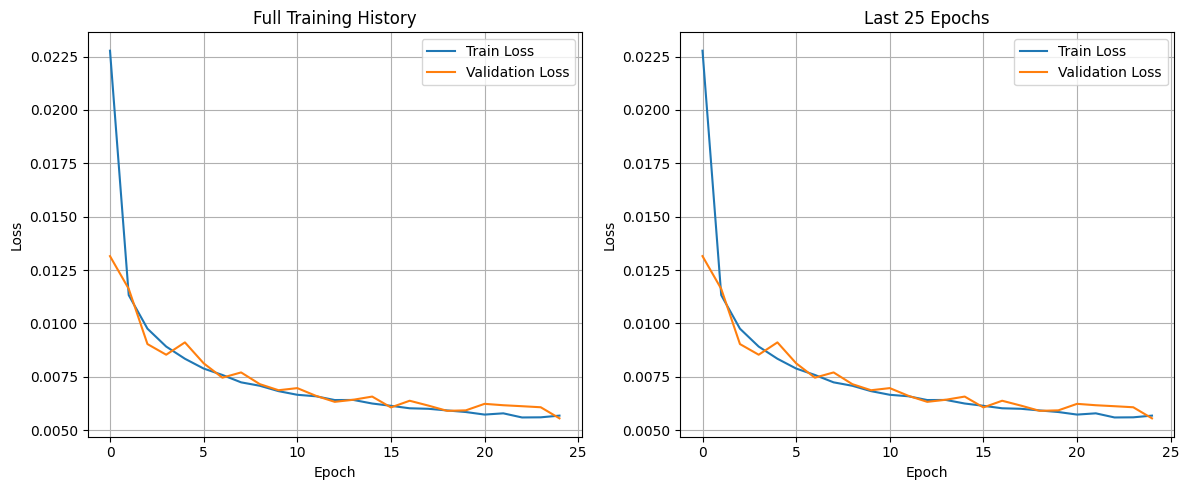

DEBUG: Plot saved and displayed successfully

Training completed in 14.11 minutes
Best validation loss: 0.005555
✓ Completed in 846.7s | Final Val Loss: 0.005555

[3/20] ================== Training basis_lat512_gnone ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 85.01M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:32<15:11, 18.93it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_checkpoint.pth


...

Epoch 29/30 | Train: 0.006215 | Val: 0.006459 | LR: 0.00010000 | ETA: 0.69m

GPU Memory Usage:
Allocated: 1384.11 MB
Cached: 1696.00 MB
CPU Memory Usage: 1986.47 MB
DEBUG: EarlyStopping - Current val_loss: 0.006459, Best loss: 0.006451
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [20:36<00:00, 18.79it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_checkpoint.pth


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [20:46<00:00, 14.32it/s]

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_metadata.json
Epoch 30/30 | Train: 0.006300 | Val: 0.006317 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 1384.11 MB
Cached: 1696.00 MB
CPU Memory Usage: 1986.48 MB
DEBUG: EarlyStopping - Current val_loss: 0.006317, Best loss: 0.006451
Validation loss improved by 0.000134
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat512_gnone/basis_lat512_gnone_training_history.png


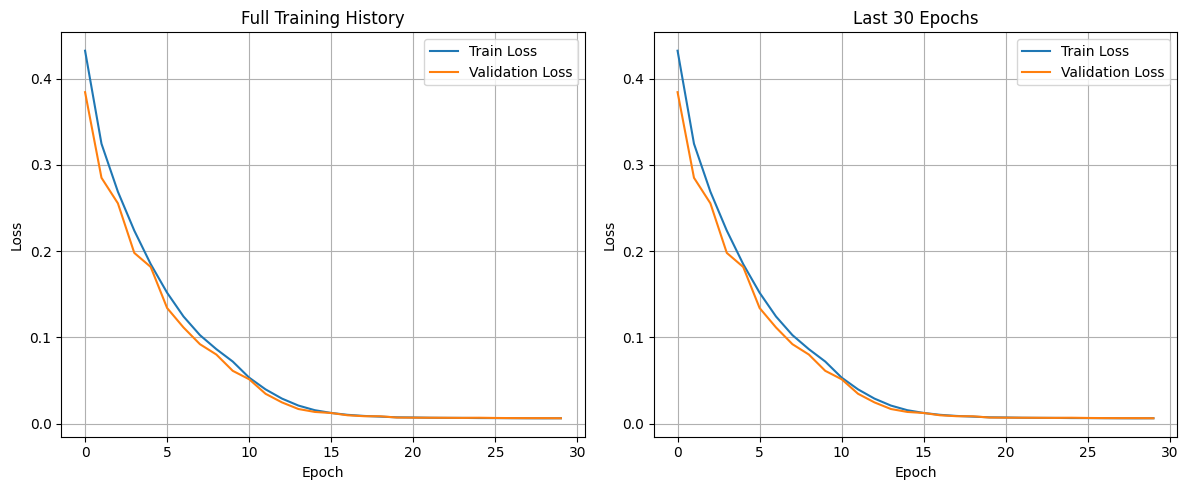

DEBUG: Plot saved and displayed successfully

Training completed in 20.78 minutes
Best validation loss: 0.006317
✓ Completed in 1246.7s | Final Val Loss: 0.006317

[4/20] ================== Training basis_lat256_gfull ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 9.21M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gfull/basis_lat256_gfull_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gfull/basis_lat256_gfull_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:22<10:36, 27.12it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [13:56<00:00, 26.29it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:02<00:00, 21.19it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gfull/basis_lat256_gfull_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gfull/basis_lat256_gfull_metadata.json
Epoch 30/30 | Train: 0.010915 | Val: 0.065669 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 1489.87 MB
Cached: 1796.00 MB
CPU Memory Usage: 1993.38 MB
DEBUG: EarlyStopping - Current val_loss: 0.065669, Best loss: 0.033327
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gfull/basis_lat256_gfull_training_history.png


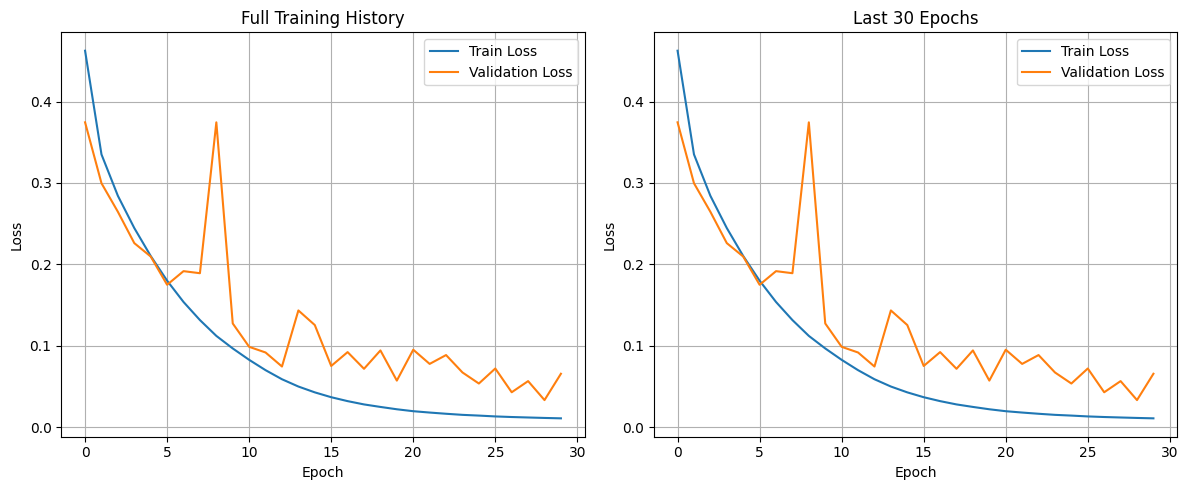

DEBUG: Plot saved and displayed successfully

Training completed in 14.05 minutes
Best validation loss: 0.033327
✓ Completed in 842.8s | Final Val Loss: 0.065669

[5/20] ================== Training basis_lat256_gpartial ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 9.40M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:25<11:56, 24.07it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_metadata.json
Epoch 29/30 | Train: 0.005812 | Val: 0.005888 | LR: 0.00010000 | ETA: 0.52m

GPU Memory Usage:
Allocated: 143.62 MB
Cached: 264.00 MB
CPU Memory Usage: 2007.24 MB
DEBUG: EarlyStopping - Current val_loss: 0.005888, Best loss: 0.005951
Validation loss improved by 0.000063
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [15:25<00:00, 24.38it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [15:31<00:00, 19.16it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_metadata.json
Epoch 30/30 | Train: 0.005949 | Val: 0.005911 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 143.62 MB
Cached: 264.00 MB
CPU Memory Usage: 2008.90 MB
DEBUG: EarlyStopping - Current val_loss: 0.005911, Best loss: 0.005888
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gpartial/basis_lat256_gpartial_training_history.png


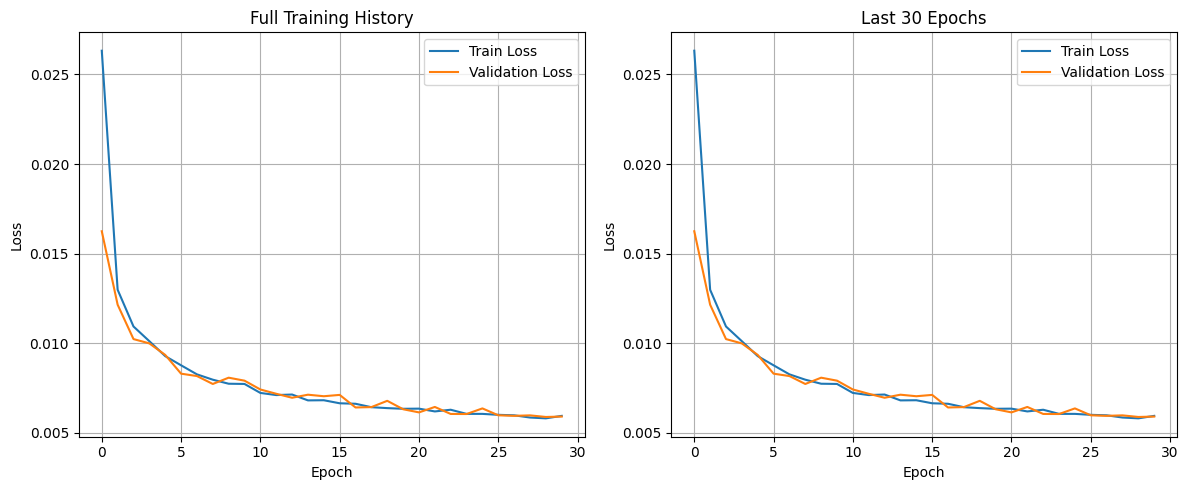

DEBUG: Plot saved and displayed successfully

Training completed in 15.53 minutes
Best validation loss: 0.005888
✓ Completed in 931.8s | Final Val Loss: 0.005911

[6/20] ================== Training basis_lat256_gnone ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 26.07M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:26<12:39, 22.72it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_checkpoint.pth


...

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_metadata.json
Epoch 29/30 | Train: 0.005619 | Val: 0.005664 | LR: 0.00010000 | ETA: 0.55m

GPU Memory Usage:
Allocated: 406.86 MB
Cached: 492.00 MB
CPU Memory Usage: 2015.52 MB
DEBUG: EarlyStopping - Current val_loss: 0.005664, Best loss: 0.005807
Validation loss improved by 0.000143
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [16:23<00:00, 22.97it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_checkpoint.pth


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [16:29<00:00, 18.03it/s]

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_metadata.json
Epoch 30/30 | Train: 0.005581 | Val: 0.005505 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 406.86 MB
Cached: 492.00 MB
CPU Memory Usage: 2015.52 MB
DEBUG: EarlyStopping - Current val_loss: 0.005505, Best loss: 0.005664
Validation loss improved by 0.000159
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat256_gnone/basis_lat256_gnone_training_history.png


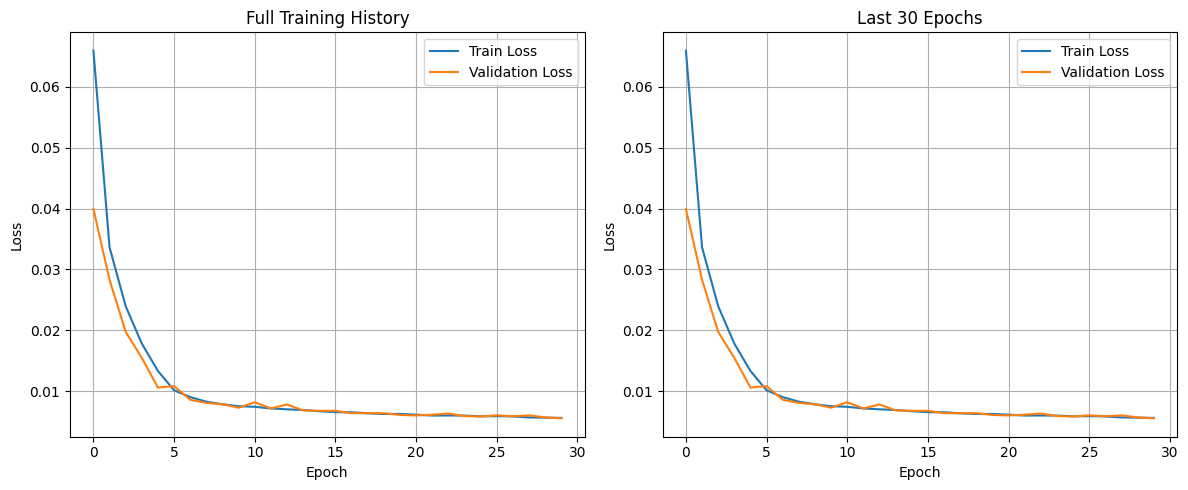

DEBUG: Plot saved and displayed successfully

Training completed in 16.50 minutes
Best validation loss: 0.005505
✓ Completed in 990.2s | Final Val Loss: 0.005505

[7/20] ================== Training basis_lat128_gfull ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 4.97M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:24<11:21, 25.34it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_metadata.json
Epoch 29/30 | Train: 0.084540 | Val: 0.082916 | LR: 0.00010000 | ETA: 0.49m

GPU Memory Usage:
Allocated: 464.46 MB
Cached: 552.00 MB
CPU Memory Usage: 2029.43 MB
DEBUG: EarlyStopping - Current val_loss: 0.082916, Best loss: 0.086111
Validation loss improved by 0.003194
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:32<00:00, 24.78it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_checkpoint.pth


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:37<00:00, 20.34it/s]

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_metadata.json
Epoch 30/30 | Train: 0.081613 | Val: 0.080098 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 464.46 MB
Cached: 552.00 MB
CPU Memory Usage: 2029.43 MB
DEBUG: EarlyStopping - Current val_loss: 0.080098, Best loss: 0.082916
Validation loss improved by 0.002818
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gfull/basis_lat128_gfull_training_history.png


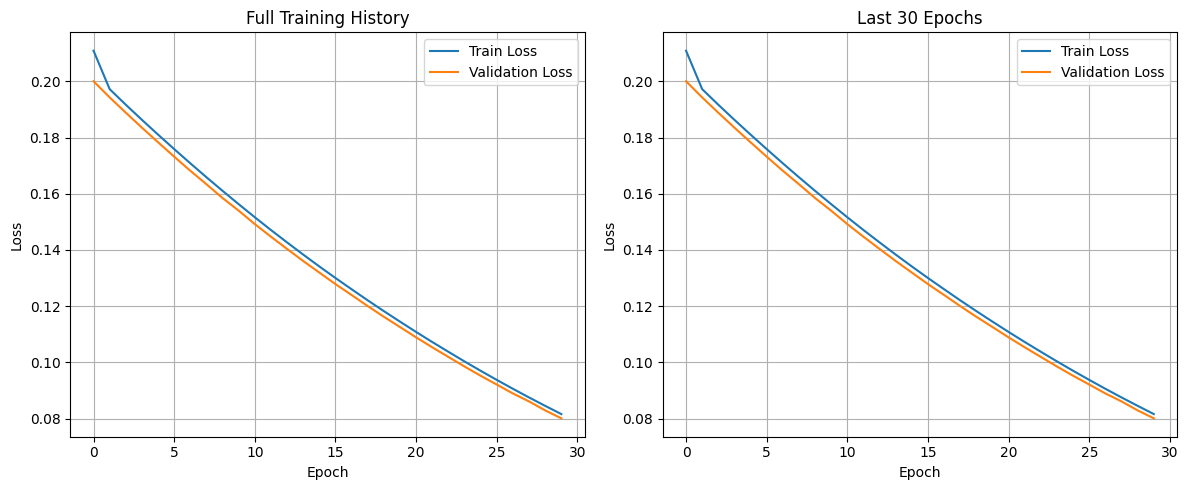

DEBUG: Plot saved and displayed successfully

Training completed in 14.64 minutes
Best validation loss: 0.080098
✓ Completed in 878.1s | Final Val Loss: 0.080098

[8/20] ================== Training basis_lat128_gpartial ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 5.07M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gpartial/basis_lat128_gpartial_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gpartial/basis_lat128_gpartial_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:24<11:37, 24.74it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Epoch 29/30 | Train: 0.006129 | Val: 0.006196 | LR: 0.00010000 | ETA: 0.49m

GPU Memory Usage:
Allocated: 523.19 MB
Cached: 620.00 MB
CPU Memory Usage: 2035.55 MB
DEBUG: EarlyStopping - Current val_loss: 0.006196, Best loss: 0.006093
Early stopping counter: 2/5
DEBUG: EarlyStopping - No improvement, counter increased to 2/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:31<00:00, 25.08it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:36<00:00, 20.37it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gpartial/basis_lat128_gpartial_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gpartial/basis_lat128_gpartial_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gpartial/basis_lat128_gpartial_metadata.json
Epoch 30/30 | Train: 0.006080 | Val: 0.006022 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 523.19 MB
Cached: 620.00 MB
CPU Memory Usage: 2035.55 MB
DEBUG: EarlyStopping - Current val_loss: 0.006022, Best loss: 0.006093
Validation loss improved by 0.000071
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gpartial/basis_lat128_gpartial_training_history.png


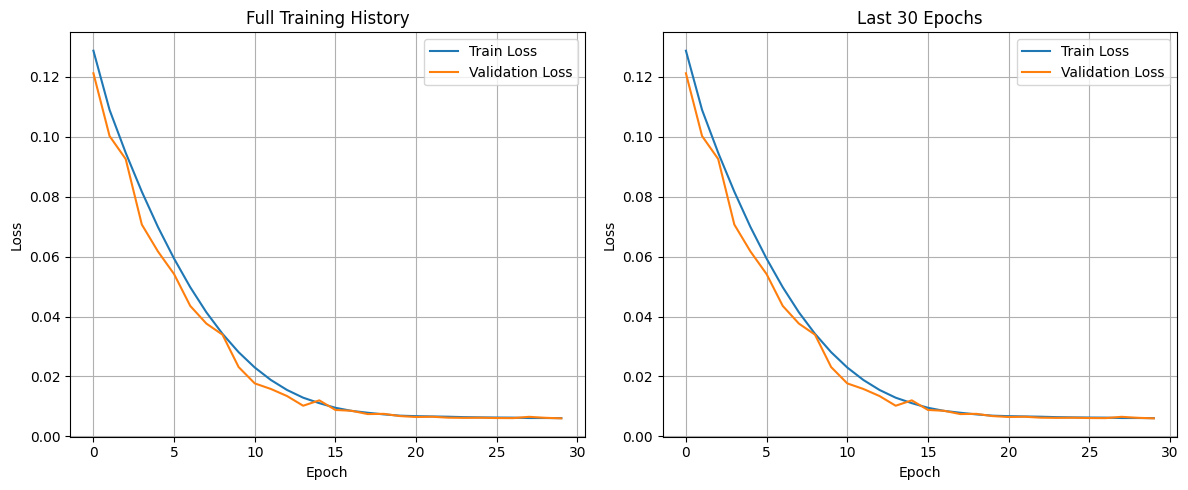

DEBUG: Plot saved and displayed successfully

Training completed in 14.61 minutes
Best validation loss: 0.006022
✓ Completed in 876.8s | Final Val Loss: 0.006022

[9/20] ================== Training basis_lat128_gnone ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 9.18M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


IOPub message rate exceeded.|▎                                                       | 89/17850 [00:03<11:53, 24.88it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Progress [E9/30|Val]:  30%|████████████████▊                                       | 5355/17850 [04:21<08:17, 25.12it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 8


...

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_metadata.json
Epoch 29/30 | Train: 0.005705 | Val: 0.005679 | LR: 0.00010000 | ETA: 0.49m

GPU Memory Usage:
Allocated: 629.27 MB
Cached: 700.00 MB
CPU Memory Usage: 2039.64 MB
DEBUG: EarlyStopping - Current val_loss: 0.005679, Best loss: 0.005716
Validation loss improved by 0.000037
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:41<00:00, 25.09it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:46<00:00, 20.14it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_metadata.json
Epoch 30/30 | Train: 0.005566 | Val: 0.005686 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 629.27 MB
Cached: 700.00 MB
CPU Memory Usage: 2039.64 MB
DEBUG: EarlyStopping - Current val_loss: 0.005686, Best loss: 0.005679
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat128_gnone/basis_lat128_gnone_training_history.png


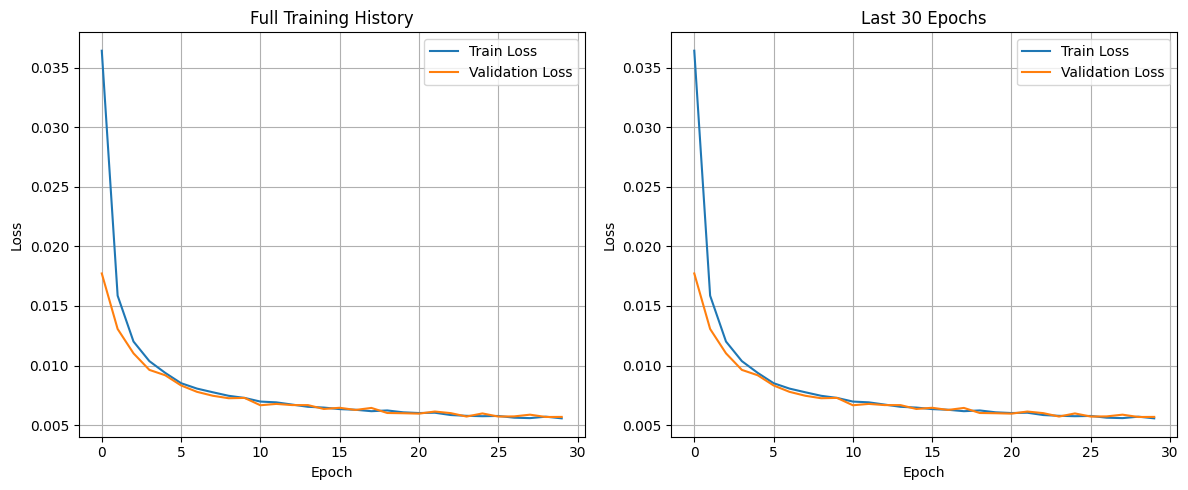

DEBUG: Plot saved and displayed successfully

Training completed in 14.78 minutes
Best validation loss: 0.005679
✓ Completed in 887.2s | Final Val Loss: 0.005686

[10/20] ================== Training basis_lat64_gfull ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 2.85M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E2/30|Train]:   3%|█▊                                                     | 595/17850 [00:28<11:07, 25.85it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_metadata.json
Epoch 1/30 | Train: 0.024506 | Val: 0.016604 | LR: 0.00010000 | ETA: 13.84m

GPU Memory Usage:
Allocated: 662.95 MB
Cached: 730.00 MB
CPU Memory Usage: 2041.80 MB
DEBUG: EarlyStopping - Current val_loss: 0.016604, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 2/30


...

Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:54<00:23, 25.65it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 28
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_metadata.json
Epoch 29/30 | Train: 0.006595 | Val: 0.006538 | LR: 0.00010000 | ETA: 0.48m

GPU Memory Usage:
Allocated: 662.95 MB
Cached: 730.00 MB
CPU Memory Usage: 2042.11 MB
DEBUG: EarlyStopping - Current val_loss: 0.006538, Best loss: 0.006703
Validation loss improved by 0.000166
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:22<00:00, 20.69it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_metadata.json
Epoch 30/30 | Train: 0.006481 | Val: 0.006690 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 662.95 MB
Cached: 730.00 MB
CPU Memory Usage: 2042.12 MB
DEBUG: EarlyStopping - Current val_loss: 0.006690, Best loss: 0.006538
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gfull/basis_lat64_gfull_training_history.png


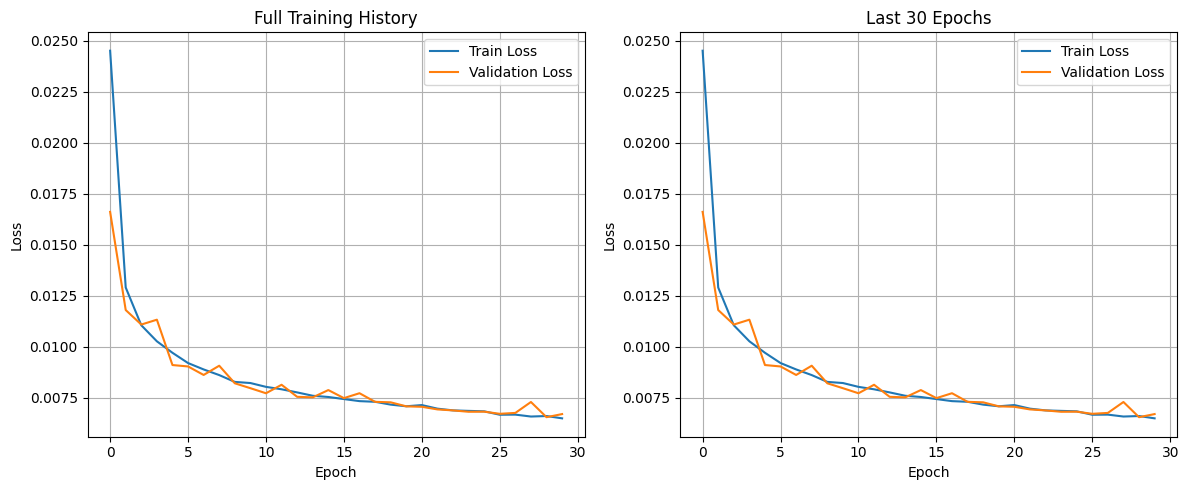

DEBUG: Plot saved and displayed successfully

Training completed in 14.39 minutes
Best validation loss: 0.006538
✓ Completed in 863.3s | Final Val Loss: 0.006690

[11/20] ================== Training basis_lat64_gpartial ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 2.90M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E2/30|Train]:   3%|█▊                                                     | 595/17850 [00:28<11:02, 26.04it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_metadata.json
Epoch 1/30 | Train: 0.039330 | Val: 0.017679 | LR: 0.00010000 | ETA: 13.94m

GPU Memory Usage:
Allocated: 697.19 MB
Cached: 750.00 MB
CPU Memory Usage: 2043.00 MB
DEBUG: EarlyStopping - Current val_loss: 0.017679, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 2/30


...

Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:55<00:23, 25.36it/s]

Epoch 29/30 | Train: 0.005977 | Val: 0.006393 | LR: 0.00010000 | ETA: 0.48m

GPU Memory Usage:
Allocated: 697.19 MB
Cached: 750.00 MB
CPU Memory Usage: 2046.40 MB
DEBUG: EarlyStopping - Current val_loss: 0.006393, Best loss: 0.006012
Early stopping counter: 4/5
DEBUG: EarlyStopping - No improvement, counter increased to 4/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:24<00:00, 20.66it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_metadata.json
Epoch 30/30 | Train: 0.005949 | Val: 0.005908 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 697.19 MB
Cached: 750.00 MB
CPU Memory Usage: 2046.43 MB
DEBUG: EarlyStopping - Current val_loss: 0.005908, Best loss: 0.006012
Validation loss improved by 0.000104
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gpartial/basis_lat64_gpartial_training_history.png


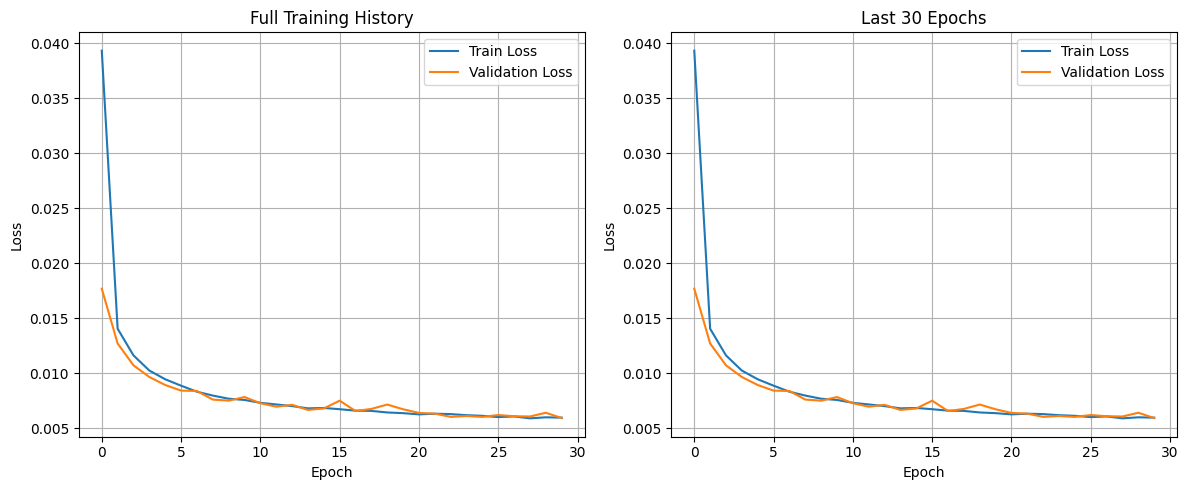

DEBUG: Plot saved and displayed successfully

Training completed in 14.41 minutes
Best validation loss: 0.005908
✓ Completed in 864.5s | Final Val Loss: 0.005908

[12/20] ================== Training basis_lat64_gnone ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 3.88M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:23<11:16, 25.49it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_checkpoint.pth


...

Epoch 29/30 | Train: 0.006125 | Val: 0.006142 | LR: 0.00010000 | ETA: 0.48m

GPU Memory Usage:
Allocated: 742.33 MB
Cached: 788.00 MB
CPU Memory Usage: 2053.91 MB
DEBUG: EarlyStopping - Current val_loss: 0.006142, Best loss: 0.006133
Early stopping counter: 3/5
DEBUG: EarlyStopping - No improvement, counter increased to 3/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:16<00:00, 23.04it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_checkpoint.pth


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:21<00:00, 20.72it/s]

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_metadata.json
Epoch 30/30 | Train: 0.006019 | Val: 0.006038 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 742.33 MB
Cached: 788.00 MB
CPU Memory Usage: 2053.93 MB
DEBUG: EarlyStopping - Current val_loss: 0.006038, Best loss: 0.006133
Validation loss improved by 0.000095
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat64_gnone/basis_lat64_gnone_training_history.png


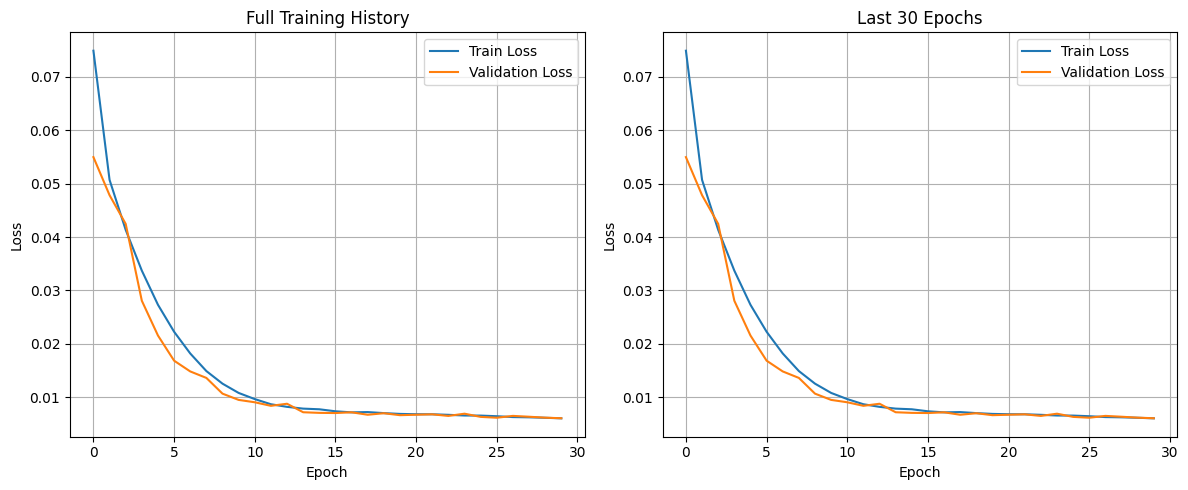

DEBUG: Plot saved and displayed successfully

Training completed in 14.37 minutes
Best validation loss: 0.006038
✓ Completed in 861.9s | Final Val Loss: 0.006038

[13/20] ================== Training basis_lat32_gfull ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 1.80M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E2/30|Train]:   3%|█▊                                                     | 595/17850 [00:28<10:47, 26.63it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_metadata.json
Epoch 1/30 | Train: 0.079151 | Val: 0.052745 | LR: 0.00010000 | ETA: 13.64m

GPU Memory Usage:
Allocated: 764.20 MB
Cached: 816.00 MB
CPU Memory Usage: 2055.18 MB
DEBUG: EarlyStopping - Current val_loss: 0.052745, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 2/30


...

Epoch 28/30 | Train: 0.007310 | Val: 0.007443 | LR: 0.00010000 | ETA: 0.95m

GPU Memory Usage:
Allocated: 764.20 MB
Cached: 816.00 MB
CPU Memory Usage: 2055.66 MB
DEBUG: EarlyStopping - Current val_loss: 0.007443, Best loss: 0.007270
Early stopping counter: 2/5
DEBUG: EarlyStopping - No improvement, counter increased to 2/5
DEBUG: Starting epoch 29/30


Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:44<00:22, 26.62it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 28
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_metadata.json
Epoch 29/30 | Train: 0.007237 | Val: 0.007172 | LR: 0.00010000 | ETA: 0.47m

GPU Memory Usage:
Allocated: 764.20 MB
Cached: 816.00 MB
CPU Memory Usage: 2055.67 MB
DEBUG: EarlyStopping - Current val_loss: 0.007172, Best loss: 0.007270
Validation loss improved by 0.000098
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:12<00:00, 20.93it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_metadata.json
Epoch 30/30 | Train: 0.007144 | Val: 0.007238 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 764.20 MB
Cached: 816.00 MB
CPU Memory Usage: 2055.67 MB
DEBUG: EarlyStopping - Current val_loss: 0.007238, Best loss: 0.007172
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gfull/basis_lat32_gfull_training_history.png


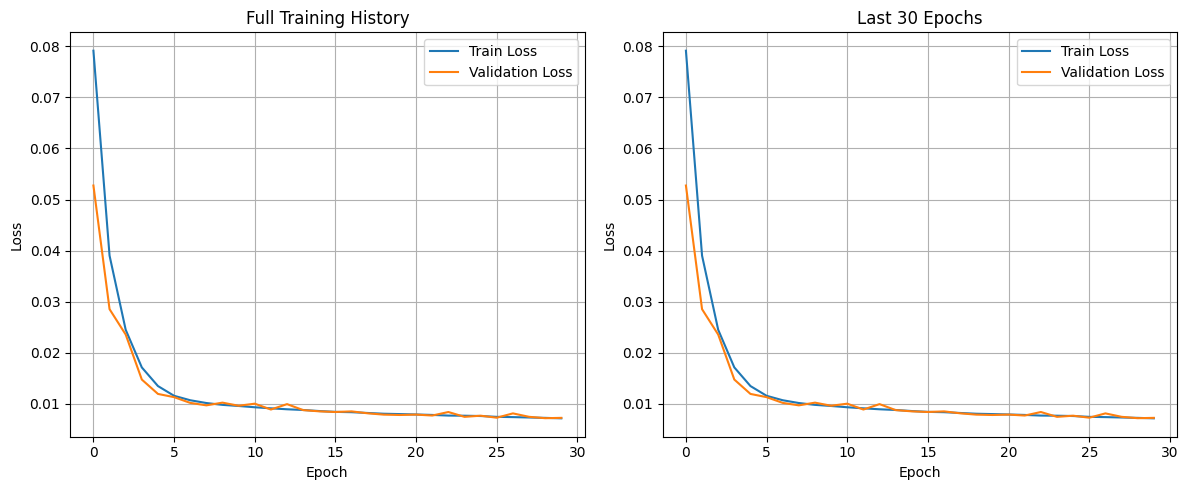

DEBUG: Plot saved and displayed successfully

Training completed in 14.22 minutes
Best validation loss: 0.007172
✓ Completed in 853.1s | Final Val Loss: 0.007238

[14/20] ================== Training basis_lat32_gpartial ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 1.82M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E2/30|Train]:   3%|█▊                                                     | 595/17850 [00:29<10:55, 26.32it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_metadata.json
Epoch 1/30 | Train: 0.561422 | Val: 0.483080 | LR: 0.00010000 | ETA: 14.16m

GPU Memory Usage:
Allocated: 785.74 MB
Cached: 844.00 MB
CPU Memory Usage: 2056.11 MB
DEBUG: EarlyStopping - Current val_loss: 0.483080, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 2/30


...

Epoch 28/30 | Train: 0.014211 | Val: 3.802840 | LR: 0.00001250 | ETA: 0.94m

GPU Memory Usage:
Allocated: 29.05 MB
Cached: 100.00 MB
CPU Memory Usage: 2056.13 MB
DEBUG: EarlyStopping - Current val_loss: 3.802840, Best loss: 0.197866
Early stopping counter: 20/5
DEBUG: EarlyStopping - No improvement, counter increased to 20/5
Early stopping triggered. Best epoch was 7.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Starting epoch 29/30


Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:40<00:22, 26.43it/s]

Epoch 29/30 | Train: 0.013845 | Val: 2.216440 | LR: 0.00001250 | ETA: 0.47m

GPU Memory Usage:
Allocated: 29.05 MB
Cached: 100.00 MB
CPU Memory Usage: 2056.13 MB
DEBUG: EarlyStopping - Current val_loss: 2.216440, Best loss: 0.197866
Early stopping counter: 21/5
DEBUG: EarlyStopping - No improvement, counter increased to 21/5
Early stopping triggered. Best epoch was 7.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:07<00:00, 21.05it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_metadata.json
Epoch 30/30 | Train: 0.013333 | Val: 2.170823 | LR: 0.00001250 | ETA: 0.00m

GPU Memory Usage:
Allocated: 29.05 MB
Cached: 100.00 MB
CPU Memory Usage: 2056.13 MB
DEBUG: EarlyStopping - Current val_loss: 2.170823, Best loss: 0.197866
Early stopping counter: 22/5
DEBUG: EarlyStopping - No improvement, counter increased to 22/5
Early stopping triggered. Best epoch was 7.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gpartial/basis_lat32_gpartial_training_h

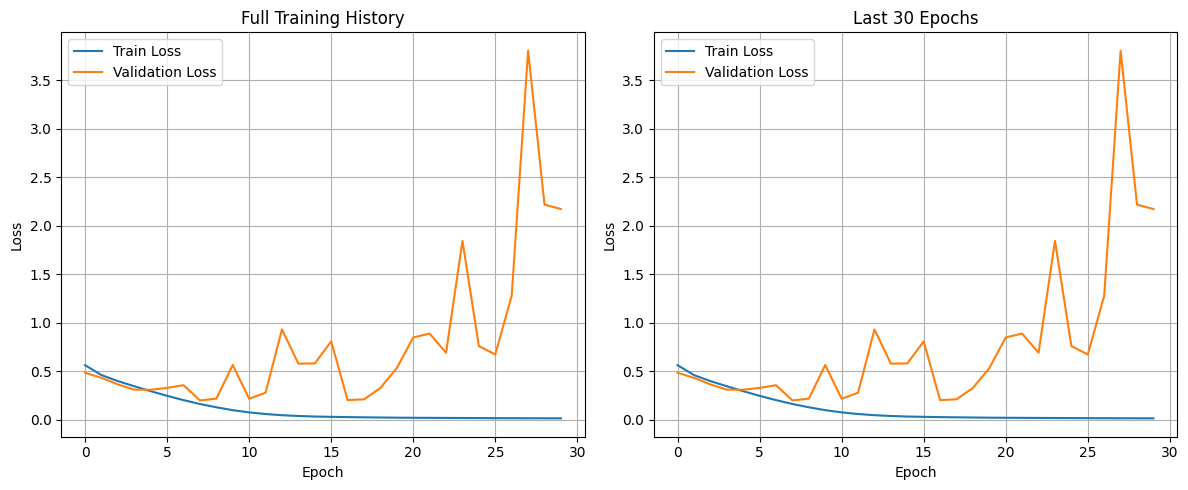

DEBUG: Plot saved and displayed successfully

Training completed in 14.14 minutes
Best validation loss: 0.197866
✓ Completed in 848.3s | Final Val Loss: 2.170823

[15/20] ================== Training basis_lat32_gnone ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 2.02M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E2/30|Train]:   3%|█▊                                                     | 595/17850 [00:28<11:08, 25.81it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_metadata.json
Epoch 1/30 | Train: 0.060230 | Val: 0.039867 | LR: 0.00010000 | ETA: 13.77m

GPU Memory Usage:
Allocated: 45.04 MB
Cached: 98.00 MB
CPU Memory Usage: 2056.29 MB
DEBUG: EarlyStopping - Current val_loss: 0.039867, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 2/30


...

Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:53<00:23, 25.46it/s]

Epoch 29/30 | Train: 0.006262 | Val: 0.006260 | LR: 0.00010000 | ETA: 0.48m

GPU Memory Usage:
Allocated: 45.04 MB
Cached: 98.00 MB
CPU Memory Usage: 2056.30 MB
DEBUG: EarlyStopping - Current val_loss: 0.006260, Best loss: 0.006158
Early stopping counter: 3/5
DEBUG: EarlyStopping - No improvement, counter increased to 3/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:22<00:00, 20.70it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_metadata.json
Epoch 30/30 | Train: 0.006220 | Val: 0.006204 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 45.04 MB
Cached: 98.00 MB
CPU Memory Usage: 2056.30 MB
DEBUG: EarlyStopping - Current val_loss: 0.006204, Best loss: 0.006158
Early stopping counter: 4/5
DEBUG: EarlyStopping - No improvement, counter increased to 4/5
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/basis_lat32_gnone/basis_lat32_gnone_training_history.png


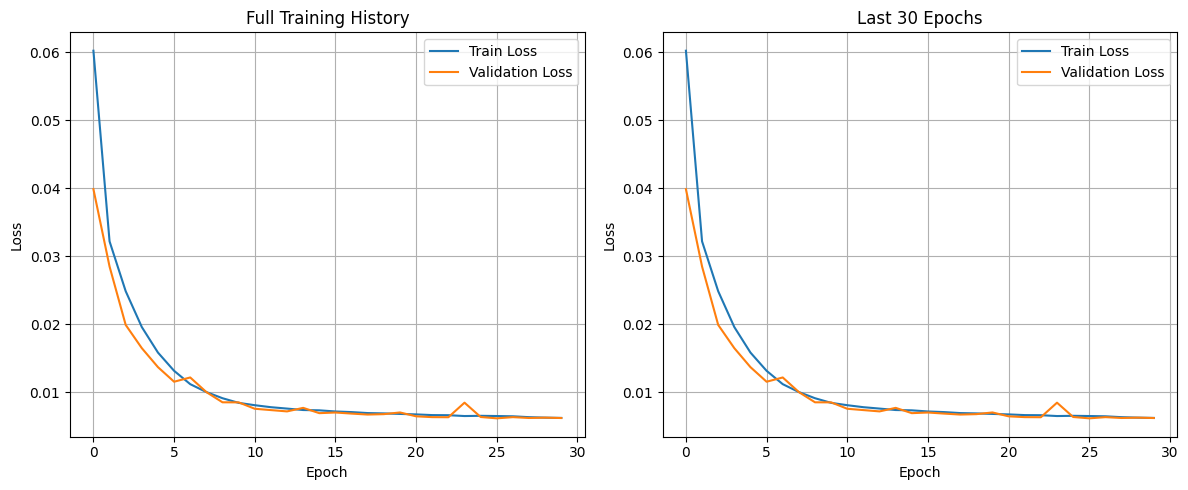

DEBUG: Plot saved and displayed successfully

Training completed in 14.38 minutes
Best validation loss: 0.006158
✓ Completed in 862.6s | Final Val Loss: 0.006204

[16/20] ================== Training deconv_lat512 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 25.90M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat512/deconv_lat512_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat512/deconv_lat512_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:23<11:12, 25.65it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat512/deconv_lat512_checkpoint.pth


...

Epoch 29/30 | Train: 0.004522 | Val: 0.004888 | LR: 0.00010000 | ETA: 0.49m

GPU Memory Usage:
Allocated: 341.55 MB
Cached: 448.00 MB
CPU Memory Usage: 2057.02 MB
DEBUG: EarlyStopping - Current val_loss: 0.004888, Best loss: 0.004882
Early stopping counter: 3/5
DEBUG: EarlyStopping - No improvement, counter increased to 3/5
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:44<00:00, 25.69it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:50<00:00, 20.04it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat512/deconv_lat512_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat512/deconv_lat512_metadata.json
Epoch 30/30 | Train: 0.004494 | Val: 0.005564 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 341.55 MB
Cached: 448.00 MB
CPU Memory Usage: 2057.02 MB
DEBUG: EarlyStopping - Current val_loss: 0.005564, Best loss: 0.004882
Early stopping counter: 4/5
DEBUG: EarlyStopping - No improvement, counter increased to 4/5
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat512/deconv_lat512_training_history.png


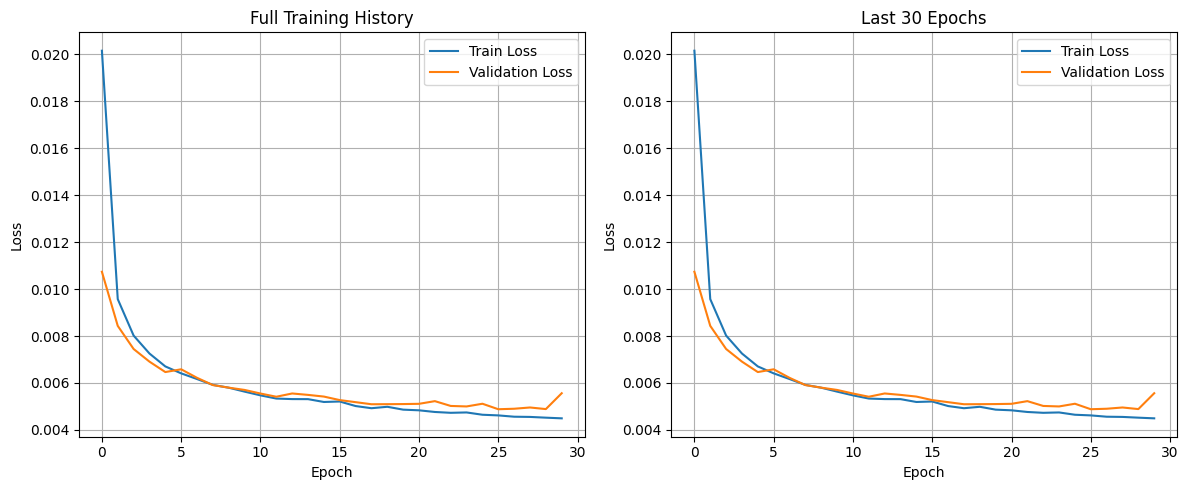

DEBUG: Plot saved and displayed successfully

Training completed in 14.85 minutes
Best validation loss: 0.004882
✓ Completed in 891.2s | Final Val Loss: 0.005564

[17/20] ================== Training deconv_lat256 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 13.32M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:23<11:07, 25.86it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_metadata.json
Epoch 29/30 | Train: 0.004715 | Val: 0.004870 | LR: 0.00010000 | ETA: 0.48m

GPU Memory Usage:
Allocated: 494.68 MB
Cached: 570.00 MB
CPU Memory Usage: 2057.39 MB
DEBUG: EarlyStopping - Current val_loss: 0.004870, Best loss: 0.005060
Validation loss improved by 0.000190
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:23<00:00, 25.85it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:29<00:00, 20.54it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_metadata.json
Epoch 30/30 | Train: 0.004774 | Val: 0.004916 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 494.68 MB
Cached: 570.00 MB
CPU Memory Usage: 2057.39 MB
DEBUG: EarlyStopping - Current val_loss: 0.004916, Best loss: 0.004870
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat256/deconv_lat256_training_history.png


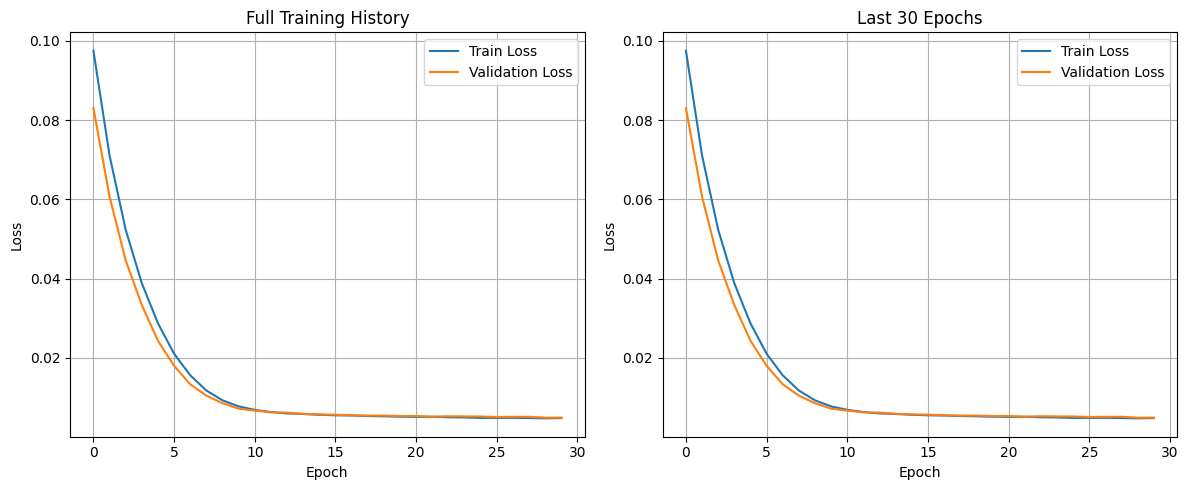

DEBUG: Plot saved and displayed successfully

Training completed in 14.49 minutes
Best validation loss: 0.004870
✓ Completed in 869.6s | Final Val Loss: 0.004916

[18/20] ================== Training deconv_lat128 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 7.03M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat128/deconv_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat128/deconv_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:23<11:02, 26.03it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:12<00:00, 26.33it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:17<00:00, 20.82it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat128/deconv_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat128/deconv_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat128/deconv_lat128_metadata.json
Epoch 30/30 | Train: 0.004603 | Val: 0.004724 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 576.13 MB
Cached: 648.00 MB
CPU Memory Usage: 2065.45 MB
DEBUG: EarlyStopping - Current val_loss: 0.004724, Best loss: 0.004731
Validation loss improved by 0.000007
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat128/deconv_lat128_training_history.png


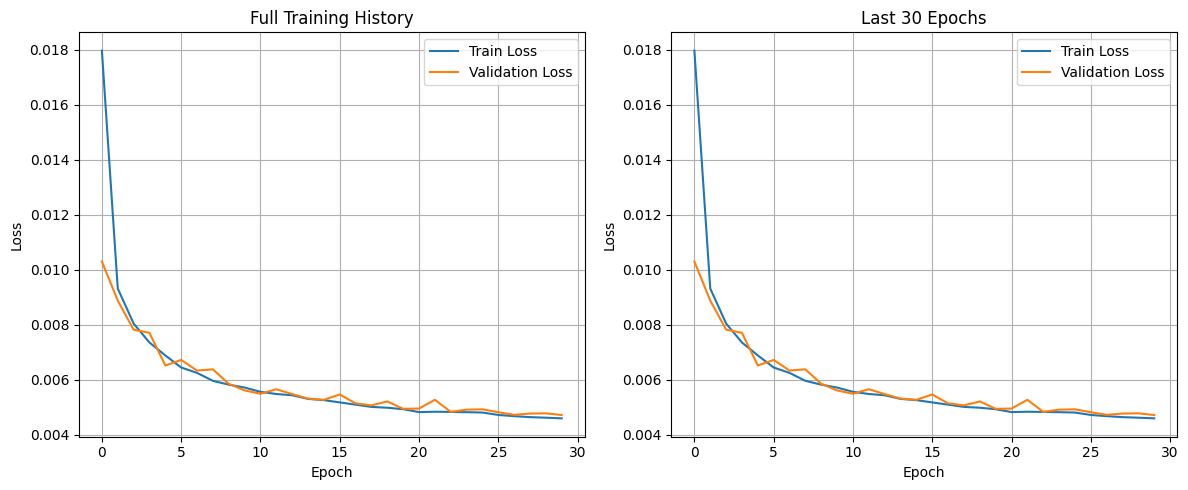

DEBUG: Plot saved and displayed successfully

Training completed in 14.30 minutes
Best validation loss: 0.004724
✓ Completed in 857.8s | Final Val Loss: 0.004724

[19/20] ================== Training deconv_lat64 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 3.88M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat64/deconv_lat64_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat64/deconv_lat64_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E1/30|Val]:   3%|█▉                                                       | 595/17850 [00:23<11:46, 24.42it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat64/deconv_lat64_checkpoint.pth


...

Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:39<00:22, 26.15it/s]

Epoch 29/30 | Train: 0.021246 | Val: 3.123329 | LR: 0.00001250 | ETA: 0.47m

GPU Memory Usage:
Allocated: 621.57 MB
Cached: 702.00 MB
CPU Memory Usage: 2065.52 MB
DEBUG: EarlyStopping - Current val_loss: 3.123329, Best loss: 0.179763
Early stopping counter: 23/5
DEBUG: EarlyStopping - No improvement, counter increased to 23/5
Early stopping triggered. Best epoch was 5.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [14:07<00:00, 21.06it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat64/deconv_lat64_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat64/deconv_lat64_metadata.json
Epoch 30/30 | Train: 0.020506 | Val: 2.521134 | LR: 0.00000625 | ETA: 0.00m

GPU Memory Usage:
Allocated: 621.57 MB
Cached: 702.00 MB
CPU Memory Usage: 2065.52 MB
DEBUG: EarlyStopping - Current val_loss: 2.521134, Best loss: 0.179763
Early stopping counter: 24/5
DEBUG: EarlyStopping - No improvement, counter increased to 24/5
Early stopping triggered. Best epoch was 5.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat64/deconv_lat64_training_history.png


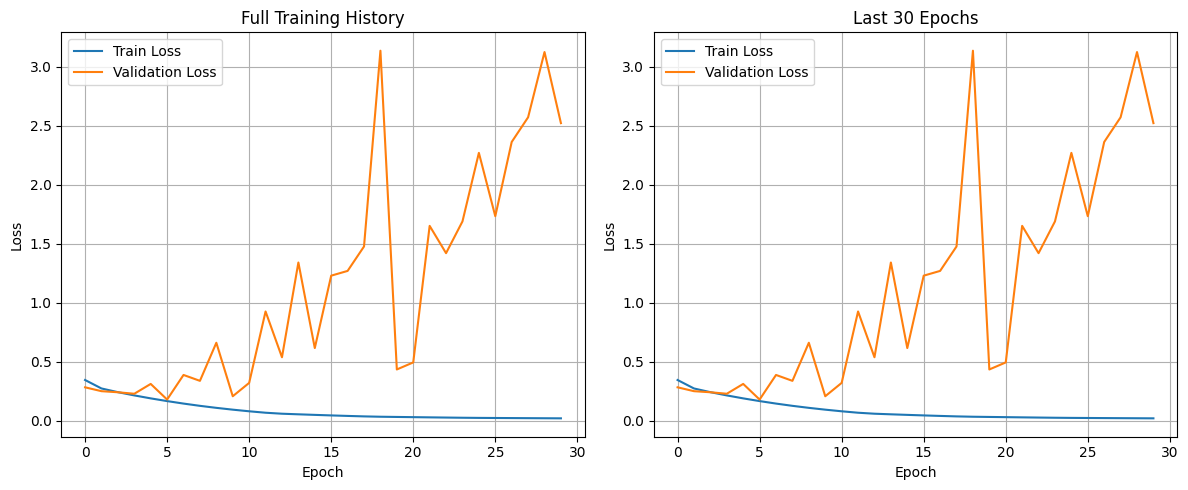

DEBUG: Plot saved and displayed successfully

Training completed in 14.13 minutes
Best validation loss: 0.179763
✓ Completed in 848.0s | Final Val Loss: 2.521134

[20/20] ================== Training deconv_lat32 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 2.31M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/30|Train]:   0%|                                                                 | 0/17850 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/30


Progress [E2/30|Train]:   3%|█▊                                                     | 595/17850 [00:27<10:35, 27.14it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_metadata.json
Epoch 1/30 | Train: 0.471969 | Val: 0.414101 | LR: 0.00010000 | ETA: 13.29m

GPU Memory Usage:
Allocated: 649.33 MB
Cached: 758.00 MB
CPU Memory Usage: 2065.57 MB
DEBUG: EarlyStopping - Current val_loss: 0.414101, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 2/30


...

Progress [E30/30|Train]:  97%|██████████████████████████████████████████████████▎ | 17255/17850 [13:16<00:21, 27.27it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 28
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_metadata.json
Epoch 29/30 | Train: 0.008215 | Val: 0.007906 | LR: 0.00010000 | ETA: 0.46m

GPU Memory Usage:
Allocated: 649.33 MB
Cached: 758.00 MB
CPU Memory Usage: 2065.58 MB
DEBUG: EarlyStopping - Current val_loss: 0.007906, Best loss: 0.008427
Validation loss improved by 0.000521
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Starting epoch 30/30


Progress [E30/30|Val]: 100%|██████████████████████████████████████████████████████| 17850/17850 [13:44<00:00, 21.65it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 29
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_checkpoint.pth
Saved best model to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_metadata.json
Epoch 30/30 | Train: 0.007777 | Val: 0.007504 | LR: 0.00010000 | ETA: 0.00m

GPU Memory Usage:
Allocated: 649.33 MB
Cached: 758.00 MB
CPU Memory Usage: 2065.58 MB
DEBUG: EarlyStopping - Current val_loss: 0.007504, Best loss: 0.007906
Validation loss improved by 0.000402
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottelneckBestModel-12-11/deconv_lat32/deconv_lat32_training_history.png


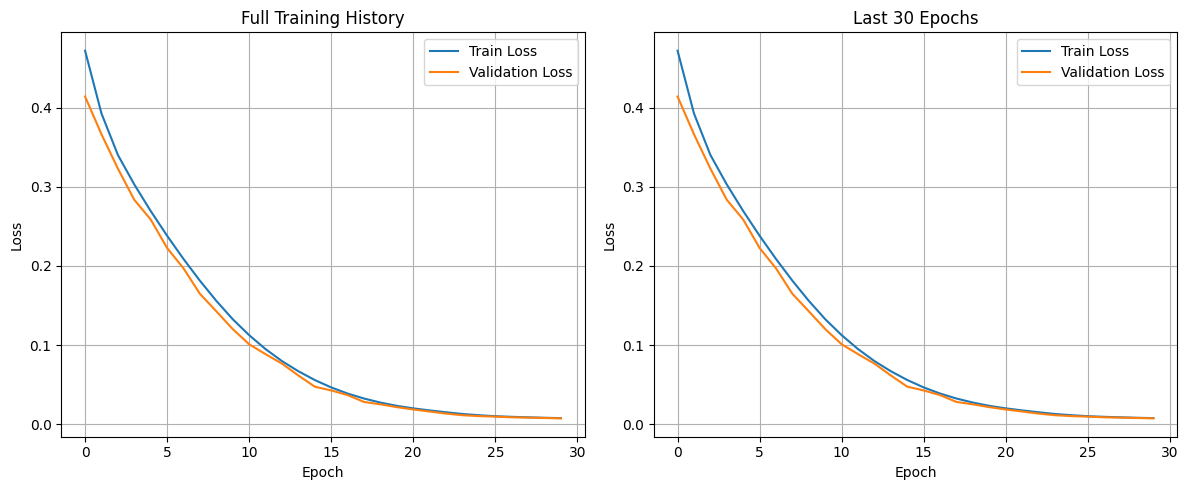

DEBUG: Plot saved and displayed successfully

Training completed in 13.76 minutes
Best validation loss: 0.007504
✓ Completed in 825.8s | Final Val Loss: 0.007504


In [9]:
import time

for idx, (variant, latent_dim, bshape, groups) in enumerate(settings):
    model_name = f"{variant}_lat{latent_dim}_g{groups}" if variant == "basis" else f"{variant}_lat{latent_dim}"
    print(f"\n[{idx+1}/{len(settings)}] ================== Training {model_name} ==================")
    
    cfg = create_training_config(model_name, num_epochs)
    model = build_model(variant, latent_dim=latent_dim, bottleneck_shape=bshape, basis_groups=groups)
    
    # Count parameters
    num_params = count_trainable(model)
    print(f"Parameters: {num_params / 1e6:.2f}M")
    
    # Time the training
    start_time = time.time()
    
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=None,  # default MSE
    )
    
    elapsed_time = time.time() - start_time
    
    histories[model_name] = {"train": train_losses, "val": val_losses}
    results_summary.append({
        "Variant": variant,
        "Latent Dim": latent_dim,
        "Groups": groups if variant == "basis" else "N/A",
        "Parameters": num_params,
        "Final Val Loss": val_losses[-1],
        "Best Val Loss": min(val_losses),
        "Training Time (s)": elapsed_time,
        "Time per Epoch (s)": elapsed_time / num_epochs,
    })
    
    print(f"✓ Completed in {elapsed_time:.1f}s | Final Val Loss: {val_losses[-1]:.6f}")

In [10]:
count_trainable(model)

2309873

## Evaluation

In [14]:
# Create comprehensive results dataframe
results_df = pd.DataFrame(results_summary)
results_df["Params (M)"] = results_df["Parameters"] / 1e6
results_df["Speed (samples/sec)"] = (len(train_loader.dataset) / results_df["Time per Epoch (s)"]).round(1)

# Sort by validation loss
results_df_sorted = results_df.sort_values("Best Val Loss")

print("\n" + "="*100)
print("TOP 10 FASTEST MODELS (by validation loss)")
print("="*100)
display(results_df_sorted[["Variant", "Latent Dim", "Groups", "Params (M)", "Best Val Loss", "Time per Epoch (s)"]].head(10))

# Find fastest model
fastest_idx = results_df["Time per Epoch (s)"].idxmin()
fastest = results_df.iloc[fastest_idx]
print(f"\n⚡ FASTEST MODEL: {fastest['Variant']} (latent_dim={fastest['Latent Dim']}, groups={fastest['Groups']})")
print(f"   Time per epoch: {fastest['Time per Epoch (s)']:.2f}s")
print(f"   Parameters: {fastest['Params (M)']:.2f}M")
print(f"   Validation Loss: {fastest['Best Val Loss']:.6f}")


TOP 10 FASTEST MODELS (by validation loss)


,Variant,Latent Dim,Groups,Params (M),Best Val Loss,Time per Epoch (s)
17,deconv,128,N/A,7.028561,0.004724,28.592397
16,deconv,256,N/A,13.320145,0.004870,28.986162
15,deconv,512,N/A,25.903313,0.004882,29.705246
5,basis,256,none,26.069137,0.005505,33.006142
1,basis,512,partial,18.072273,0.005555,28.224303
8,basis,128,none,9.181073,0.005679,29.572473
4,basis,256,partial,9.404625,0.005888,31.058858
10,basis,64,partial,2.903889,0.005908,28.815596
7,basis,128,partial,5.070801,0.006022,29.225793
11,basis,64,none,3.882769,0.006038,28.731085



⚡ FASTEST MODEL: deconv (latent_dim=32, groups=N/A)
   Time per epoch: 27.53s
   Parameters: 2.31M
   Validation Loss: 0.007504


In [ ]:
# Create results summary dataframe
results_data = []
for variant, latent_dim, bshape, groups in settings:
    if variant in histories:
        history = histories[variant]
        results_data.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Bottleneck Shape": str(bshape),
            "Groups": groups,
            "Final Train Loss": history["train"][-1],
            "Final Val Loss": history["val"][-1],
            "Best Val Loss": min(history["val"]),
            "Parameters": count_parameters(build_model(variant, latent_dim, bshape, groups))
        })

results_df = pd.DataFrame(results_data)
results_df["Params (M)"] = results_df["Parameters"] / 1e6
display(results_df)

In [ ]:
# Plot training and validation losses
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training losses
for variant in histories.keys():
    axes[0].plot(histories[variant]["train"], label=variant, linewidth=2)
axes[0].set_title("Training Loss Comparison", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation losses
for variant in histories.keys():
    axes[1].plot(histories[variant]["val"], label=variant, linewidth=2)
axes[1].set_title("Validation Loss Comparison", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Find best model based on validation loss
best_variant = min(results_df.to_dict('records'), key=lambda x: x['Best Val Loss'])

print("="*80)
print("BEST MODEL SUMMARY")
print("="*80)
print(f"Variant: {best_variant['Variant']}")
print(f"Latent Dimension: {best_variant['Latent Dim']}")
print(f"Bottleneck Shape: {best_variant['Bottleneck Shape']}")
print(f"Groups: {best_variant['Groups']}")
print(f"Parameters: {best_variant['Params (M)']:.3f}M")
print(f"Best Validation Loss: {best_variant['Best Val Loss']:.6f}")
print(f"Final Train Loss: {best_variant['Final Train Loss']:.6f}")
print(f"Final Val Loss: {best_variant['Final Val Loss']:.6f}")
print("="*80)

In [ ]:
# Plot parameter count vs validation loss
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    results_df["Params (M)"], 
    results_df["Final Val Loss"],
    s=200, 
    alpha=0.7,
    c=range(len(results_df)),
    cmap='viridis'
)

for idx, row in results_df.iterrows():
    plt.annotate(
        row['Variant'], 
        (row["Params (M)"], row["Final Val Loss"]),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel("Parameters (Millions)", fontsize=12)
plt.ylabel("Final Validation Loss", fontsize=12)
plt.title("Parameter Efficiency: Model Size vs Performance", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "param_efficiency.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Load a validation sample and visualize reconstructions
val_iter = iter(val_loader)
sample_batch = next(val_iter)

# Handle dict output from dataloader - key is 'volume' not 'image'
if isinstance(sample_batch, dict):
    sample_input = sample_batch['volume'].to(device)
elif isinstance(sample_batch, (list, tuple)):
    sample_input = sample_batch[0].to(device)
else:
    sample_input = sample_batch.to(device)

# Select middle slice for visualization
slice_idx = sample_input.shape[2] // 2

fig, axes = plt.subplots(1, len(settings) + 1, figsize=(20, 4))

# Original
axes[0].imshow(sample_input[0, 0, slice_idx].cpu().numpy(), cmap='gray')
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Reconstructions
for idx, (variant, latent_dim, bshape, groups) in enumerate(settings):
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Look for best model checkpoint (contains only model weights)
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    best_model_path = os.path.join(checkpoint_dir, f"{variant}_lat{latent_dim}_best.pth")
    
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        with torch.no_grad():
            output = model(sample_input)
        
        axes[idx + 1].imshow(output[0, 0, slice_idx].cpu().numpy(), cmap='gray')
        axes[idx + 1].set_title(f'{variant}\n(Val Loss: {histories[variant]["val"][-1]:.6f})', 
                                fontsize=10, fontweight='bold')
        axes[idx + 1].axis('off')
    else:
        axes[idx + 1].text(0.5, 0.5, 'No checkpoint\nfound', ha='center', va='center', 
                          transform=axes[idx + 1].transAxes, fontsize=10)
        axes[idx + 1].set_title(f'{variant}', fontsize=10)
        axes[idx + 1].axis('off')
        print(f"⚠️ Checkpoint not found: {best_model_path}")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "reconstruction_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Compute reconstruction metrics for each model
reconstruction_metrics = []

for variant, latent_dim, bshape, groups in settings:
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Look for best model checkpoint (contains only model weights)
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    best_model_path = os.path.join(checkpoint_dir, f"{variant}_lat{latent_dim}_best.pth")
    
    if os.path.exists(best_model_path):
        print(f"✓ Evaluating {variant} using {os.path.basename(best_model_path)}...")
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        all_mse = []
        all_mae = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Evaluating {variant}", leave=False):
                # Handle dict output from dataloader - key is 'volume' not 'image'
                if isinstance(batch, dict):
                    inputs = batch['volume'].to(device)
                elif isinstance(batch, (list, tuple)):
                    inputs = batch[0].to(device)
                else:
                    inputs = batch.to(device)
                
                outputs = model(inputs)
                
                # Compute metrics
                mse = F.mse_loss(outputs, inputs).item()
                mae = F.l1_loss(outputs, inputs).item()
                
                all_mse.append(mse)
                all_mae.append(mae)
        
        reconstruction_metrics.append({
            "Variant": variant,
            "Avg MSE": np.mean(all_mse),
            "Std MSE": np.std(all_mse),
            "Avg MAE": np.mean(all_mae),
            "Std MAE": np.std(all_mae),
            "Min MSE": np.min(all_mse),
            "Max MSE": np.max(all_mse)
        })
    else:
        print(f"⚠️ No checkpoint found for {variant} at {best_model_path}")

if reconstruction_metrics:
    metrics_df = pd.DataFrame(reconstruction_metrics)
    display(metrics_df)
else:
    print("\n❌ No reconstruction metrics computed.")

In [ ]:
# Check what checkpoint files exist
print("Checking checkpoint directories:\n")
for variant, latent_dim, bshape, groups in settings:
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    print(f"📁 {variant}_lat{latent_dim}:")
    
    if os.path.exists(checkpoint_dir):
        files = os.listdir(checkpoint_dir)
        pth_files = [f for f in files if f.endswith('.pth')]
        
        if pth_files:
            print(f"   ✓ Found {len(pth_files)} checkpoint(s):")
            for pth in sorted(pth_files):
                file_path = os.path.join(checkpoint_dir, pth)
                size_mb = os.path.getsize(file_path) / (1024 * 1024)
                print(f"     - {pth} ({size_mb:.2f} MB)")
        else:
            print(f"   ⚠️ No .pth files found")
            print(f"     Files in directory: {files}")
    else:
        print(f"   ❌ Directory does not exist")
    print()

In [ ]:
# Analyze training convergence
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss curves (log scale)
for variant in histories.keys():
    axes[0, 0].semilogy(histories[variant]["val"], label=variant, linewidth=2)
axes[0, 0].set_title("Validation Loss (Log Scale)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Log MSE Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Loss improvement from epoch 0
for variant in histories.keys():
    initial_loss = histories[variant]["val"][0]
    improvement = [(initial_loss - loss) / initial_loss * 100 for loss in histories[variant]["val"]]
    axes[0, 1].plot(improvement, label=variant, linewidth=2)
axes[0, 1].set_title("Validation Loss Improvement (%)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Improvement from Initial (%)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Train-Val gap
for variant in histories.keys():
    gap = [t - v for t, v in zip(histories[variant]["train"], histories[variant]["val"])]
    axes[1, 0].plot(gap, label=variant, linewidth=2)
axes[1, 0].set_title("Train-Validation Gap", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Train Loss - Val Loss")
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Final comparison bar chart
variants_list = list(histories.keys())
final_train = [histories[v]["train"][-1] for v in variants_list]
final_val = [histories[v]["val"][-1] for v in variants_list]

x = np.arange(len(variants_list))
width = 0.35
axes[1, 1].bar(x - width/2, final_train, width, label='Train', alpha=0.8)
axes[1, 1].bar(x + width/2, final_val, width, label='Validation', alpha=0.8)
axes[1, 1].set_title("Final Loss Comparison", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Model Variant")
axes[1, 1].set_ylabel("MSE Loss")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(variants_list, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "convergence_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Collect timing and memory statistics
timing_memory_stats = []

for variant, latent_dim, bshape, groups in settings:
    # Build model to get memory stats
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Get training history
    if variant in histories:
        history = histories[variant]
        total_epochs = len(history["train"])
        
        # Calculate time per epoch (you'll need to record this during training)
        # For now, we'll estimate based on model complexity
        # In future, modify the training loop to record actual times
        
        # Memory usage estimation
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        
        dummy_input = torch.randn(batch_size, 1, 64, 128, 128).to(device)
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        
        timing_memory_stats.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Total Epochs": total_epochs,
            "Parameters": count_parameters(model),
            "Peak Memory (MB)": peak_memory_mb
        })

timing_df = pd.DataFrame(timing_memory_stats)
timing_df["Params (M)"] = timing_df["Parameters"] / 1e6

display(timing_df)